<a href="https://colab.research.google.com/github/CPernet/Identification_likelihood_in_NeuroImaging_data/blob/main/ratings_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analysis of the expert rating on neuroimaging data type privacy**

After having genrated lists of neuroimaging data types and evidences for 'risks of identification', two versions of a survey was created. Experts had to rate, for each neuroimaging data type, the likelhood of re-identification and the likelihood of single-out.

*   the data sheet contains the rating from 18 experts (2'9).
*   the columns order is rating ability to identify then ability to single out, and this pattern is repeated over 33 items

The code below, merges the data and analyse providing median ratings and correlations.

## Clone github repository to get the data

In [1]:
!git clone https://github.com/CPernet/Identification_likelihood_in_NeuroImaging_data.git

Cloning into 'Identification_likelihood_in_NeuroImaging_data'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 32 (delta 12), reused 17 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 1.12 MiB | 5.02 MiB/s, done.
Resolving deltas: 100% (12/12), done.


Experts were split into 2 groups, such as questions were not ordered the same to avoid order bias. The first task is thus to assemble into one table.

In [2]:
!ls Identification_likelihood_in_NeuroImaging_data/data/ratings

'DELPHI rating v1 - privacy in neuroimaging (Responses) - Form responses 1.csv'
'DELPHI rating v2 - privacy in neuroimaging (Responses) - Form responses 1.csv'


In [3]:
import pandas as pd

file_path_v1 = 'Identification_likelihood_in_NeuroImaging_data/data/ratings/DELPHI rating v1 - privacy in neuroimaging (Responses) - Form responses 1.csv'
file_path_v2 = 'Identification_likelihood_in_NeuroImaging_data/data/ratings/DELPHI rating v2 - privacy in neuroimaging (Responses) - Form responses 1.csv'

table1 = pd.read_csv(file_path_v1)
#print("Table1 head:\n", table1.head())
table2 = pd.read_csv(file_path_v2)
#print("\nTable2 head:\n", table2.head())

In [4]:
# CSV files are located under data/ratings
# the 1st row contains header (text) and the other rows are the numerical values/ratings
# 1st import as table1 DELPHI rating v1 - privacy in neuroimaging (Responses) - Form responses 1.csv
# 2nd import as table2 DELPHI rating v2 - privacy in neuroimaging (Responses) - Form responses 1.csv
# 3rd reorganize the columns of table2 following the order of table1
# 4th merge table1 and table2
import pandas as pd

# Reorganize the columns of table2 to match table1
table2_reordered = table2.reindex(columns=table1.columns)

# Merge table1 and the reordered table2
merged_table = pd.concat([table1, table2_reordered], ignore_index=True)

print("Merged table head:\n", merged_table.head())
print("\nMerged table shape:", merged_table.shape)

Merged table head:
    Raw MRI/CT data  Raw MRI/CT data.1  Face removed MRI/CT data.   \
0                2                  5                           1   
1                4                  4                           3   
2                5                  5                           3   
3                5                  5                           5   
4                5                  5                           2   

   Face removed MRI/CT data. .1  Skull stripped MRI  Skull stripped MRI.1  \
0                             5                   1                     5   
1                             4                   3                     4   
2                             3                   1                     3   
3                             5                   5                     5   
4                             3                   2                     2   

   Tissue maps (scalp, skull, GM, WM, CSF), VBM, SDM  \
0                                             

Quick 'manual' check -- from reading the tables, it is expected that the column Raw MRI/CT data has the values 2 4 5 5 5 5 4 3 5 5 2 4 5 4 5 4 4 4

In [5]:
# Expected values for 'Raw MRI/CT data'
expected_values = [2, 4, 5, 5, 5, 5, 4, 3, 5, 5, 2, 4, 5, 4, 5, 4, 4, 4]

# Actual values from the merged_table
actual_values = merged_table['Raw MRI/CT data'].tolist()

# Compare the lists
if actual_values == expected_values:
    print("The 'Raw MRI/CT data' column matches the expected values.")
else:
    print("The 'Raw MRI/CT data' column does NOT match the expected values.")
    print(f"Expected: {expected_values}")
    print(f"Actual:   {actual_values}")

The 'Raw MRI/CT data' column matches the expected values.


The merged table includes 2 types of rating: likelihood of re-identication and likelhood of singling out. This pattern is repeated for each data type. There is however one exception: Spatially normalized dynamic data (fMRI, ASL) for which likelhood of singling out is missing.

In [28]:
# First, let's define a helper function to standardize column names.
# This function will identify the base name for each data type
# (e.g., 'Raw MRI/CT data' from 'Raw MRI/CT data' and 'Raw MRI/CT data.1')
# and determine if it's a re-identification or singling-out column.

def get_column_info(col_name):
    original_col_name = col_name
    col_name_processed = col_name.strip() # Remove leading/trailing whitespace from the working copy
    col_type = None
    base_name_raw = None

    if col_name_processed.endswith('.1'):
        # Handles 'col_name.1'
        base_name_raw = col_name_processed[:-2].strip() # Remove '.1' and strip again
        col_type = 'singling_out'
    elif col_name_processed.endswith('. .1'):
        # Handles 'col_name. .1'
        base_name_raw = col_name_processed[:-4].strip() # Remove ' .1' and strip again
        col_type = 'singling_out'
    else:
        # Assume it's a re-identification column.
        base_name_raw = col_name_processed
        col_type = 're_identification'

    # Ensure consistent stripping of any trailing dots for the final base name
    base_name = base_name_raw.rstrip('.')

    return base_name, col_type, original_col_name

# Collect information for all columns in merged_table
all_col_info = [get_column_info(col) for col in merged_table.columns]

# Create mappings from clean base names to their original re-identification and singling-out column names
reid_map = {}
so_map = {}

# Also create an ordered list of base names based on their appearance in merged_table
ordered_base_names_from_merged = []

for base_name, col_type, original_col_name in all_col_info:
    if col_type == 're_identification':
        if base_name not in reid_map: # Only add if not already processed (handles duplicates in definition if any)
            reid_map[base_name] = original_col_name
            ordered_base_names_from_merged.append(base_name)
    elif col_type == 'singling_out':
        if base_name not in so_map:
            so_map[base_name] = original_col_name

# Prepare re-identification table using the desired order
reidentification_columns_to_select = []
reidentification_column_renames = {}
for base_name in ordered_base_names_from_merged:
    original_col_name = reid_map[base_name]
    reidentification_columns_to_select.append(original_col_name)
    reidentification_column_renames[original_col_name] = base_name

reidentification_table = merged_table[reidentification_columns_to_select].rename(columns=reidentification_column_renames)

# Prepare singling-out table using the desired order
singlingout_columns_to_select = []
singlingout_column_renames = {}

# Use the same ordered base names for consistency
all_expected_base_names = ordered_base_names_from_merged

for base_name in all_expected_base_names:
    if base_name in so_map:
        original_so_col_name = so_map[base_name]
        singlingout_columns_to_select.append(original_so_col_name)
        singlingout_column_renames[original_so_col_name] = base_name

# Create a partial singling-out table with only existing columns, and rename them to base names
singlingout_table_partial = merged_table[singlingout_columns_to_select].rename(columns=singlingout_column_renames)

# Reindex the singling-out table to include all expected base names as columns.
# Missing columns (like 'Spatially normalized dynamic data (fMRI, ASL)') will be filled with NaN, as requested.
singlingout_table = singlingout_table_partial.reindex(columns=all_expected_base_names)

print("\nRe-identification Table Shape:", reidentification_table.shape)
print("\nSingling-out Table Shape:", singlingout_table.shape)



Re-identification Table Shape: (18, 34)

Singling-out Table Shape: (18, 34)


### Median Rating and IQR Analysis

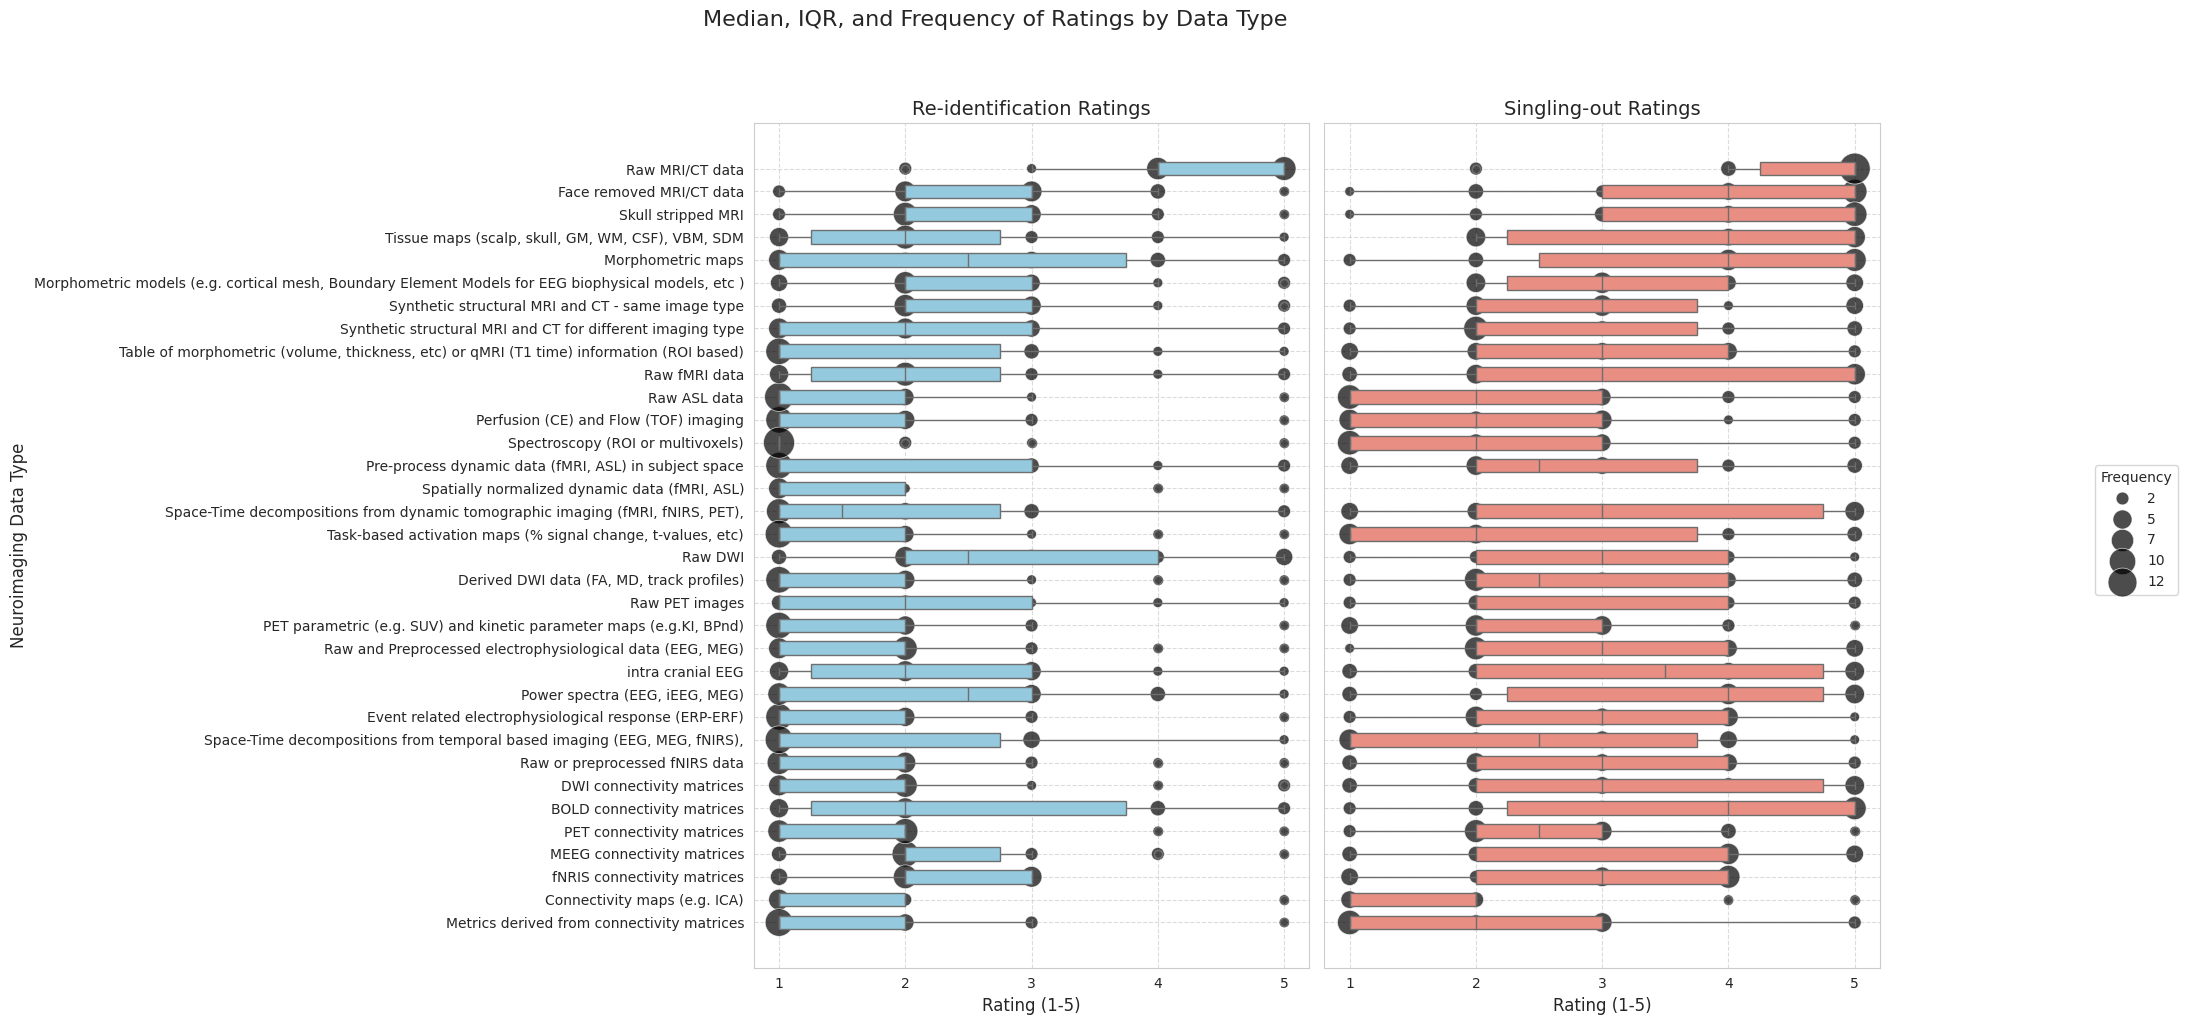

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Melt re-identification table into long format
df_reid_melted = reidentification_table.melt(
    var_name='Data Type',
    value_name='Rating'
)
df_reid_melted['Rating Type'] = 'Re-identification'

# Melt singling-out table into long format
df_so_melted = singlingout_table.melt(
    var_name='Data Type',
    value_name='Rating'
)
df_so_melted['Rating Type'] = 'Singling-out'

# Concatenate the two melted DataFrames
df_plot = pd.concat([df_reid_melted, df_so_melted], ignore_index=True)

# NEW STEP: Clean 'Data Type' for plotting display by removing 'for instance'
df_plot['Data Type'] = df_plot['Data Type'].apply(lambda x: x.split('for instance')[0].strip() if 'for instance' in x else x)

# Drop rows where Rating is NaN (this will remove the missing singling-out data for 'Spatially normalized dynamic data (fMRI, ASL)')
df_plot.dropna(subset=['Rating'], inplace=True)

# Calculate frequencies for each Data Type, Rating Type, and Rating
df_frequencies = df_plot.groupby(['Data Type', 'Rating Type', 'Rating']).size().reset_index(name='Frequency')

# Separate data for Re-identification and Singling-out plotting
df_reid_plot = df_plot[df_plot['Rating Type'] == 'Re-identification']
df_so_plot = df_plot[df_plot['Rating Type'] == 'Singling-out']

df_reid_freq = df_frequencies[df_frequencies['Rating Type'] == 'Re-identification']
df_so_freq = df_frequencies[df_frequencies['Rating Type'] == 'Singling-out']

# Calculate median re-identification ratings for each data type
median_reid_ratings_df = df_reid_plot.groupby('Data Type')['Rating'].median().reset_index()
median_reid_ratings_df.rename(columns={'Rating': 'Median Re-identification'}, inplace=True)

# Calculate median singling-out ratings for each data type
median_so_ratings_df = df_so_plot.groupby('Data Type')['Rating'].median().reset_index()
median_so_ratings_df.rename(columns={'Rating': 'Median Singling-out'}, inplace=True)

# Ensure a consistent order of data types on the y-axis, matching the order from reidentification_table
# The data_type_order needs to be cleaned as well, for consistency with df_plot
data_type_order_raw = reidentification_table.columns.tolist()
data_type_order = [s.split('for instance')[0].strip() if 'for instance' in s else s for s in data_type_order_raw]

# Get global min and max frequencies to scale marker sizes appropriately
min_global_freq = df_frequencies['Frequency'].min()
max_global_freq = df_frequencies['Frequency'].max()

# Decide on marker size range for visual clarity
marker_size_range = (50, 500) # This range will be used for both subplots

# Create the figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True) # Share y-axis for data types
sns.set_style("whitegrid")

# --- Plot Re-identification ----
ax_reid = axes[0]

# Create the boxplot for median and IQR
sns.boxplot(
    y='Data Type',
    x='Rating',
    data=df_reid_plot,
    orient='h',
    color='skyblue', # Changed from palette to color
    order=data_type_order,
    width=0.6,
    ax=ax_reid
)

# Overlay frequency points
reid_scatter = sns.scatterplot(
    y='Data Type',
    x='Rating',
    size='Frequency',
    sizes=marker_size_range, # Use consistent size range
    data=df_reid_freq,
    color='black',
    alpha=0.7,
    ax=ax_reid,
    legend='brief' # Temporarily make legend='brief' to extract handles/labels
)

ax_reid.set_title('Re-identification Ratings', fontsize=14)
ax_reid.set_xlabel('Rating (1-5)', fontsize=12)
ax_reid.set_ylabel('Neuroimaging Data Type', fontsize=12)
ax_reid.set_xticks(np.arange(1, 6, 1))
ax_reid.grid(True, linestyle='--', alpha=0.7)

# Get the legend handles and labels from the reid_scatter plot
handles, labels = reid_scatter.get_legend_handles_labels()
# Remove the legend from the ax_reid subplot
ax_reid.get_legend().remove()

# --- Plot Singling-out ---
ax_so = axes[1]

# Create the boxplot for median and IQR
sns.boxplot(
    y='Data Type',
    x='Rating',
    data=df_so_plot,
    orient='h',
    color='salmon', # Changed from palette to color
    order=data_type_order,
    width=0.6,
    ax=ax_so
)

# Overlay frequency points
sns.scatterplot(
    y='Data Type',
    x='Rating',
    size='Frequency',
    sizes=marker_size_range, # Use consistent size range
    data=df_so_freq,
    color='black',
    alpha=0.7,
    ax=ax_so,
    legend=False # Do not show legend on this subplot
)

ax_so.set_title('Singling-out Ratings', fontsize=14)
ax_so.set_xlabel('Rating (1-5)', fontsize=12)
ax_so.set_ylabel('') # No y-label for the second plot as y-axis is shared
ax_so.set_xticks(np.arange(1, 6, 1))
ax_so.grid(True, linestyle='--', alpha=0.7)

fig.suptitle('Median, IQR, and Frequency of Ratings by Data Type', fontsize=16, y=1.02) # Overall title

# Add the extracted frequency legend to the figure
# Ensure the legend title is correct, e.g., 'Frequency'
fig.legend(handles, labels, title='Frequency', bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)

plt.tight_layout(rect=[0, 0, 0.95, 0.98]) # Adjust rect to make space for the legend on the right
plt.show()

## let's check for disagreements

If an imaging data type is likely to lead to re-identification, then it is self evident that indiviudals can be single out.

It is thus relevant to group into 4 categories
- high re-identifcaion, low single out (expected count here 0) and hight re-identifcaion, high single out (all hight re-identifcaion cases)
- low re-identifcaion, low single out (basically 0 risk cases) vs low re-identifcaion, high single out  

### Neuroimaging Data Type Categorization (2x2 Table)

In [33]:
import pandas as pd

# Use the pre-calculated median ratings from cell '5a7c7a41'
# These DataFrames (median_reid_ratings_df, median_so_ratings_df) are now available in the kernel state.

# Merge the median ratings into a single DataFrame
median_ratings_df = pd.merge(median_reid_ratings_df, median_so_ratings_df, on='Data Type', how='inner')

# Define thresholds for 'low' (median < 3) and 'high' (median >= 3)
threshold = 3

# Categorize each data type
median_ratings_df['Re-identification Category'] = median_ratings_df['Median Re-identification'].apply(lambda x: 'High' if x >= threshold else 'Low')
median_ratings_df['Singling-out Category'] = median_ratings_df['Median Singling-out'].apply(lambda x: 'High' if x >= threshold else 'Low')

# Create the 2x2 categorization table
categorization_table = pd.crosstab(
    median_ratings_df['Re-identification Category'],
    median_ratings_df['Singling-out Category'],
    margins=False  # Do not include row/column sums
)

# Reorder columns and index for the desired 2x2 format (High/Low)
categorization_table = categorization_table.reindex(index=['High', 'Low'], columns=['High', 'Low'])

print("\nFrequency Count of Data Types by Median Re-identification and Singling-out Ratings (Threshold=3):\n")
print(categorization_table)

# Print the specific value for 'High Re-identification' and 'High Singling-out'
high_high_count = categorization_table.loc['High', 'High']
print(f"\nNumber of data types with High Re-identification and High Singling-out: {high_high_count}")



Frequency Count of Data Types by Median Re-identification and Singling-out Ratings (Threshold=3):

Singling-out Category       High  Low
Re-identification Category           
High                           2    0
Low                           18   13

Number of data types with High Re-identification and High Singling-out: 2


In [37]:
import pandas as pd

# Filter for data types with 'High' Re-identification and 'High' Singling-out
high_reid_high_so_data_types = median_ratings_df[
    (median_ratings_df['Re-identification Category'] == 'High') &
    (median_ratings_df['Singling-out Category'] == 'High')
]

print("\nData Types categorized as high-risks:\n")
for index, row in high_reid_high_so_data_types.iterrows():
    print(f"- {row['Data Type']}")

# Filter for data types with 'Low' Re-identification and 'Low' Singling-out (zero risk cases)
low_reid_low_so_data_types = median_ratings_df[
    (median_ratings_df['Re-identification Category'] == 'Low') &
    (median_ratings_df['Singling-out Category'] == 'Low')
]

print("\nData Types categorized as zero risk cases (Low Re-identification and Low Singling-out):\n")
for index, row in low_reid_low_so_data_types.iterrows():
    print(f"- {row['Data Type']}")

# Filter for data types with 'Low' Re-identification and 'High' Singling-out (potentially risky cases)
potentially_risky_data_types = median_ratings_df[
    (median_ratings_df['Re-identification Category'] == 'Low') &
    (median_ratings_df['Singling-out Category'] == 'High')
]

print("\nData Types categorized as potentially risky (Low Re-identification and High Singling-out):\n")
for index, row in potentially_risky_data_types.iterrows():
    print(f"- {row['Data Type']}")


Data Types categorized as high-risks:

- Face removed MRI/CT data
- Raw MRI/CT data

Data Types categorized as zero risk cases (Low Re-identification and Low Singling-out):

- Connectivity maps (e.g. ICA)
- Derived DWI data (FA, MD, track profiles)
- Metrics derived from connectivity matrices
- PET connectivity matrices
- PET parametric (e.g. SUV) and kinetic parameter maps (e.g.KI, BPnd)
- Perfusion (CE) and Flow (TOF) imaging
- Pre-process dynamic data (fMRI, ASL) in subject space
- Raw ASL data
- Raw PET images
- Space-Time decompositions from temporal based imaging (EEG, MEG, fNIRS),
- Spectroscopy (ROI or multivoxels)
- Synthetic structural MRI and CT for different imaging type
- Task-based activation maps (% signal change, t-values, etc)

Data Types categorized as potentially risky (Low Re-identification and High Singling-out):

- BOLD connectivity matrices
- DWI connectivity matrices
- Event related electrophysiological response (ERP-ERF)
- MEEG connectivity matrices
- Morphome

### Correlation Analysis

We now compute the Spearman correlation between the re-identification and singling-out ratings. Spearman correlation is suitable here as our ratings are ordinal (Likert-scale like). Missing values (NaNs) are handled by the correlation function.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Identify the column to be removed
column_to_remove = 'Spatially normalized dynamic data (fMRI, ASL)'

# Create cleaned versions of the tables by dropping the specified column
# Check if the column exists before dropping to prevent errors
reid_cleaned = reidentification_table.drop(columns=[column_to_remove]) if column_to_remove in reidentification_table.columns else reidentification_table
so_cleaned = singlingout_table.drop(columns=[column_to_remove]) if column_to_remove in singlingout_table.columns else singlingout_table


# Prepare data for combined plotting and correlation
combined_plot_data = []

# Iterate through the columns of the cleaned re-identification table
# Assuming reid_cleaned and so_cleaned have the same columns now after dropping
for col_name in reid_cleaned.columns:
    temp_df = pd.DataFrame({
        'Re-identification': reid_cleaned[col_name],
        'Singling-out': so_cleaned[col_name],
        'Data Type': col_name
    })
    # Drop rows where either re-identification or singling-out is NaN for this specific data point
    temp_df = temp_df.dropna()
    if not temp_df.empty:
        combined_plot_data.append(temp_df)

# Concatenate all data into a single DataFrame
if combined_plot_data:
    all_ratings_df = pd.concat(combined_plot_data, ignore_index=True)
else:
    all_ratings_df = pd.DataFrame(columns=['Re-identification', 'Singling-out', 'Data Type'])

# Perform overall Spearman correlation
if not all_ratings_df.empty:
    overall_corr, overall_p_value = spearmanr(all_ratings_df['Re-identification'], all_ratings_df['Singling-out'])
    print(f"\nOverall Spearman Correlation (all variables combined): {overall_corr:.3f}, P-value: {overall_p_value:.3f}")
else:
    print("No data available for overall correlation after cleaning.")


Overall Spearman Correlation (all variables combined): 0.626, P-value: 0.000


### Categorizing NeuroImaging Data Types

Variables are categorized into Data Types:  
- Structural Images: columns 1 to 9.
- Dynamic Imaging (BOLD, ASL): columns 10 to 17.
- Diffusion Imaging: columns 18 to 19.
- PET: columns 20 to 21.
- Electrophysiology (MEEG): columns 22 to 26.
- fNRIS: column 27.
Connectivity: columns 28 to 34.  

Here, we compute correlations across data at this level.

In [ ]:
# First, ensure the 'get_column_info' function is available (it was defined earlier)
# If running this cell independently, redefine 'get_column_info' if necessary.
# For the purpose of this execution, we assume it's already in the kernel state.

# Re-obtain the original ordered base names from `merged_table` to respect the user's column indexing
original_ordered_base_names = []
for col in merged_table.columns:
    base_name, col_type, _ = get_column_info(col)
    if col_type == 're_identification' and base_name not in original_ordered_base_names:
        original_ordered_base_names.append(base_name)

# Define the category definitions based on the 0-indexed positions of the original 34 columns
category_definitions_by_name = {
    "Structural Images": original_ordered_base_names[0:9], # Columns 1-9
    "Dynamic Imaging (BOLD, ASL)": original_ordered_base_names[9:17], # Columns 10-17
    "Diffusion Imaging": original_ordered_base_names[17:19], # Columns 18-19
    "PET": original_ordered_base_names[19:21], # Columns 20-21
    "Electrophysiology (MEEG)": original_ordered_base_names[21:26], # Columns 22-26
    "fNRIS": original_ordered_base_names[26:27], # Column 27
    "Connectivity": original_ordered_base_names[27:34] # Columns 28-34
}

# Create a reverse mapping for easy lookup from Data Type to Superordinate Category
data_type_to_super_category = {}
for category, data_types in category_definitions_by_name.items():
    for dt in data_types:
        data_type_to_super_category[dt] = category

# Add the 'Superordinate Category' column to all_ratings_df
# Ensure that 'Spatially normalized dynamic data (fMRI, ASL)' which was removed, is not present here.
# The .map() function will handle NaNs if a 'Data Type' is not found in the mapping, but it should be.
all_ratings_df['Superordinate Category'] = all_ratings_df['Data Type'].map(data_type_to_super_category)

print("Added 'Superordinate Category' to all_ratings_df.")
print(all_ratings_df['Superordinate Category'].value_counts())

Added 'Superordinate Category' to all_ratings_df.
Superordinate Category
Structural Images              144
Dynamic Imaging (BOLD, ASL)    126
Connectivity                   117
Electrophysiology (MEEG)        90
Diffusion Imaging               27
PET                             27
fNRIS                           18
Name: count, dtype: int64


### Grouped Spearman Correlation Analysis

Now, I will perform a separate Spearman correlation analysis for the super-ordinate categories you specified: 'Structural Images', 'Dynamic Imaging (BOLD, ASL)', 'Electrophysiology (MEEG)', and 'Connectivity'. The problematic column ('Spatially normalized dynamic data (fMRI, ASL)') is already excluded from `all_ratings_df`.

In [ ]:
# Perform Spearman correlation for each superordinate category
category_correlations = {}
if not all_ratings_df.empty and 'Superordinate Category' in all_ratings_df.columns:
    target_super_categories = [
        'Structural Images',
        'Dynamic Imaging (BOLD, ASL)',
        'Diffusion Imaging',
        'PET',
        'Electrophysiology (MEEG)',
        'fNRIS',
        'Connectivity'
    ]

    print("\nSpearman Correlation Results for Superordinate Categories:")
    for category in target_super_categories:
        filtered_df = all_ratings_df[all_ratings_df['Superordinate Category'] == category]

        if not filtered_df.empty:
            corr, p_value = spearmanr(filtered_df['Re-identification'], filtered_df['Singling-out'])
            category_correlations[category] = corr # Store the correlation
            print(f"\nCategory: {category}")
            print(f"  Correlation: {corr:.3f}")
            print(f"  P-value: {p_value:.3f}")
            print(f"  Number of data points: {len(filtered_df)}")
        else:
            print(f"\nCategory: {category} - No data available for correlation.")
elif not all_ratings_df.empty and 'Superordinate Category' not in all_ratings_df.columns:
    print("\n'Superordinate Category' column not found. Please ensure categorization is performed first.")


Spearman Correlation Results for Superordinate Categories:

Category: Structural Images
  Correlation: 0.565
  P-value: 0.000
  Number of data points: 144

Category: Dynamic Imaging (BOLD, ASL)
  Correlation: 0.656
  P-value: 0.000
  Number of data points: 126

Category: Diffusion Imaging
  Correlation: 0.502
  P-value: 0.008
  Number of data points: 27

Category: PET
  Correlation: 0.468
  P-value: 0.014
  Number of data points: 27

Category: Electrophysiology (MEEG)
  Correlation: 0.588
  P-value: 0.000
  Number of data points: 90

Category: fNRIS
  Correlation: 0.449
  P-value: 0.061
  Number of data points: 18

Category: Connectivity
  Correlation: 0.680
  P-value: 0.000
  Number of data points: 117


### Combined Scatter Plot with Superordinate Category Coloring

Finally, here is the combined scatter plot for all data types. This plot uses the jittering technique to better visualize overlapping points, and now the points are color-coded based on their `Superordinate Category`.

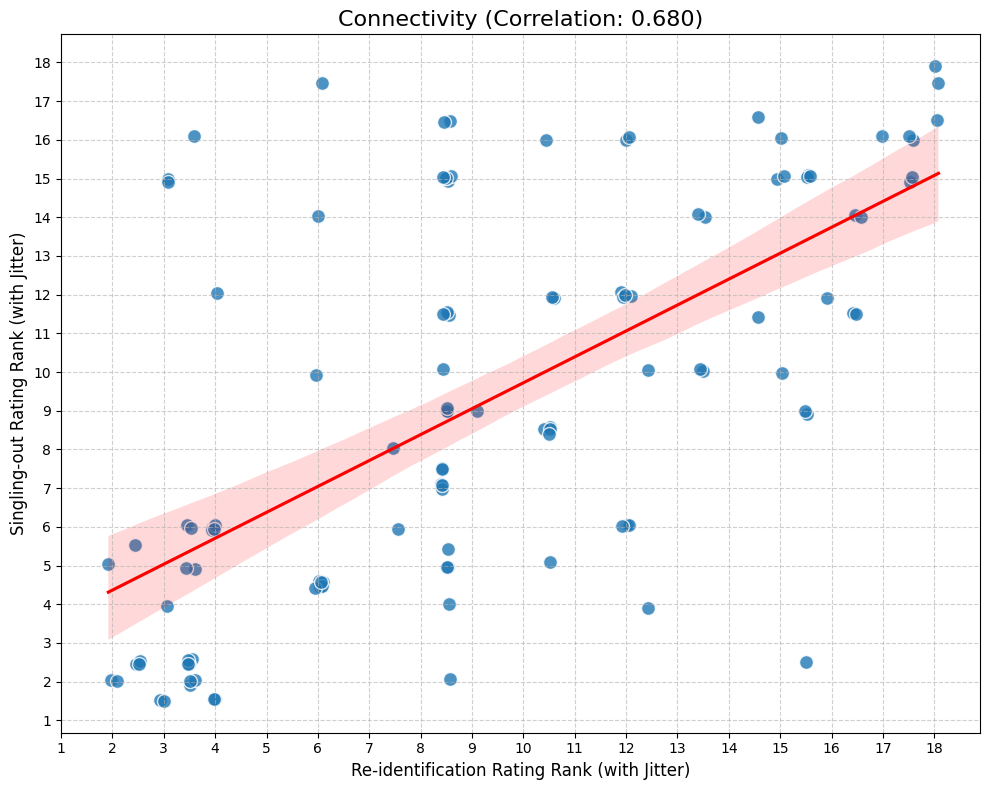

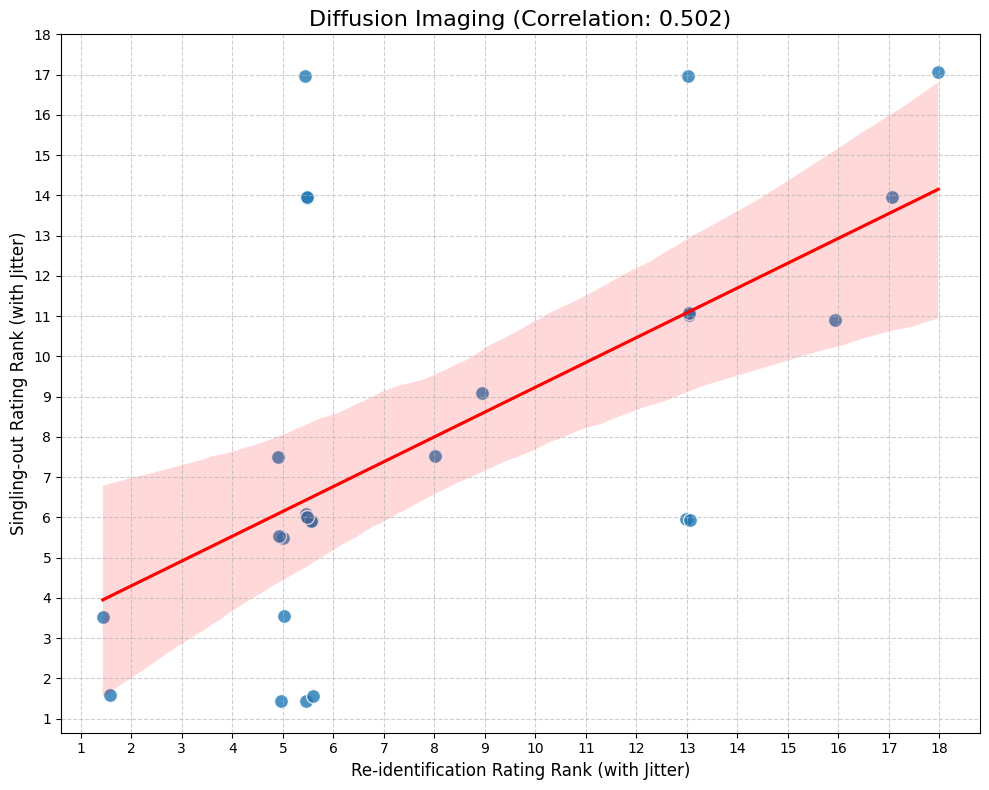

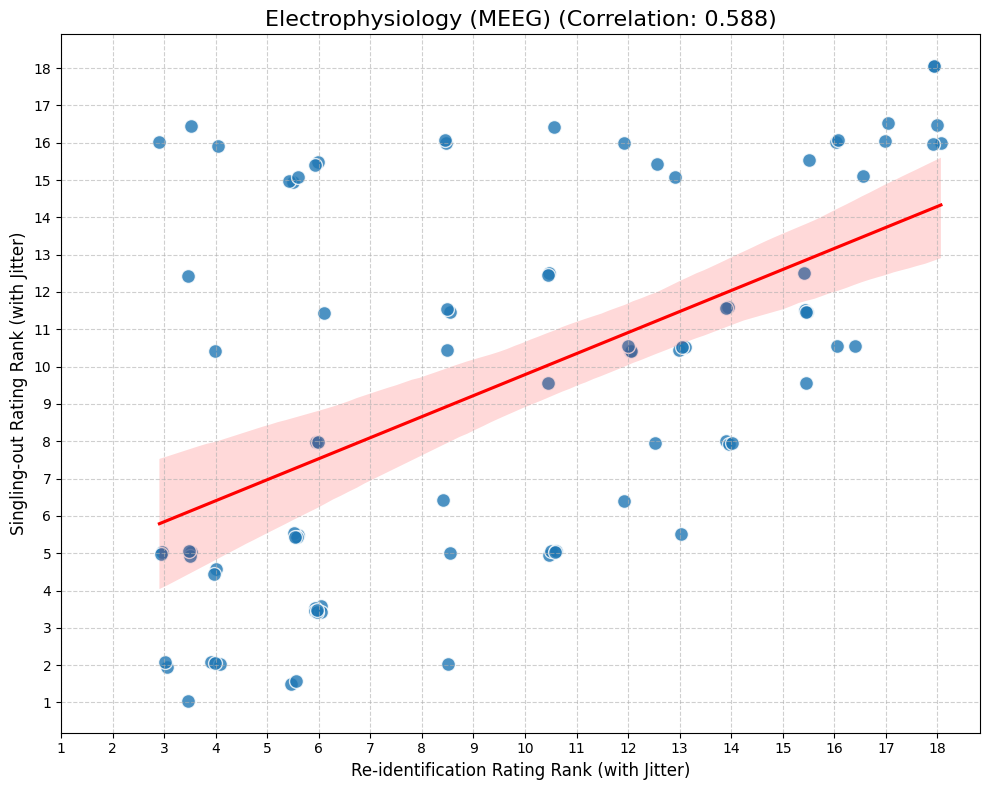

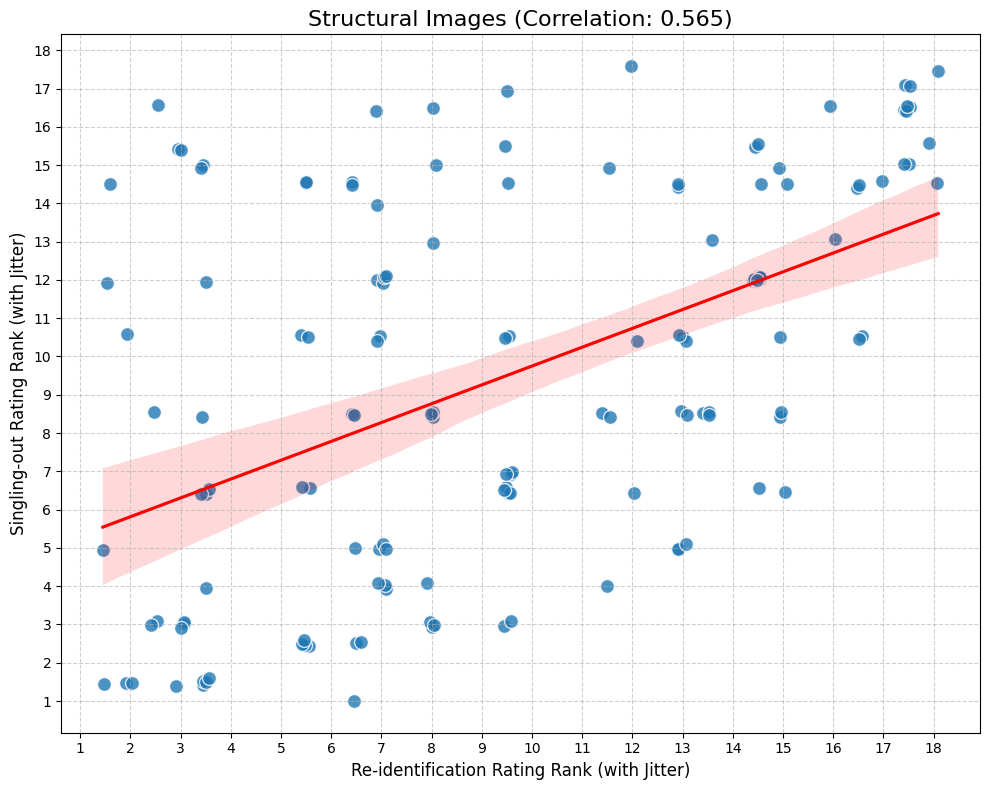

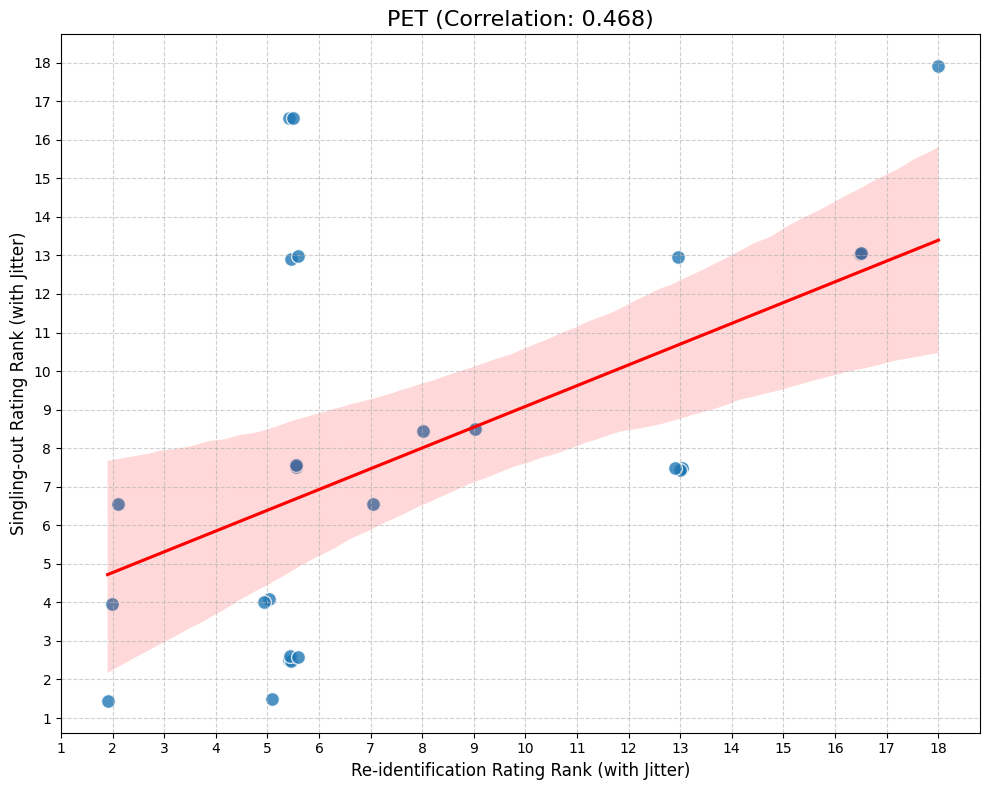

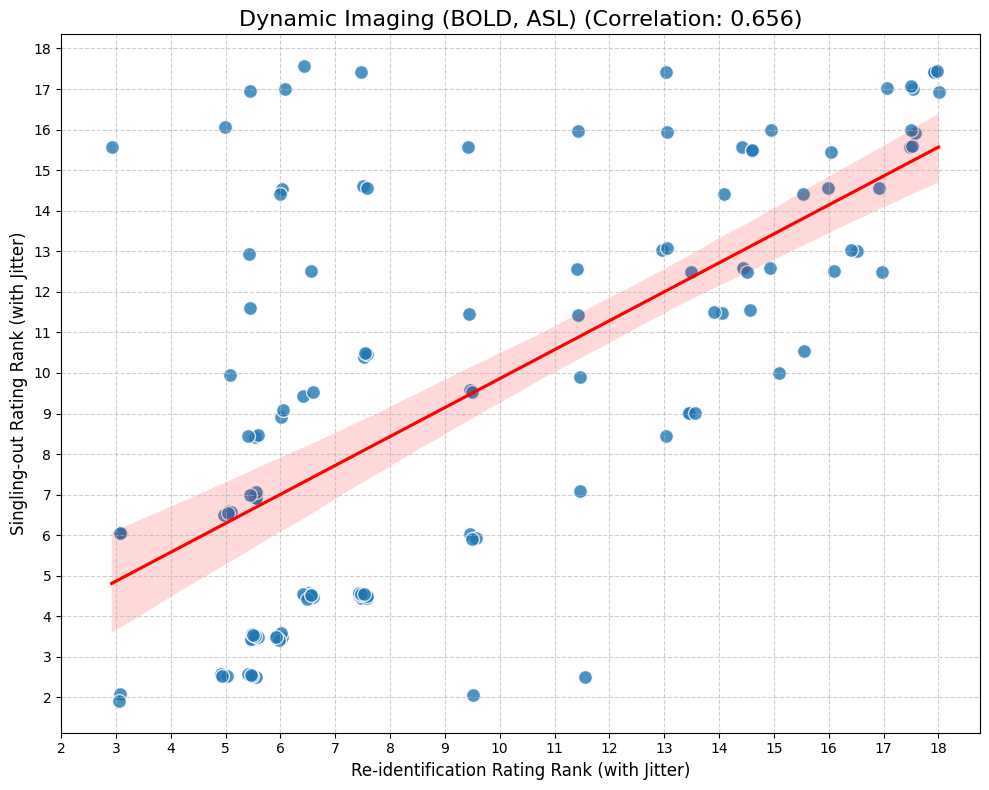

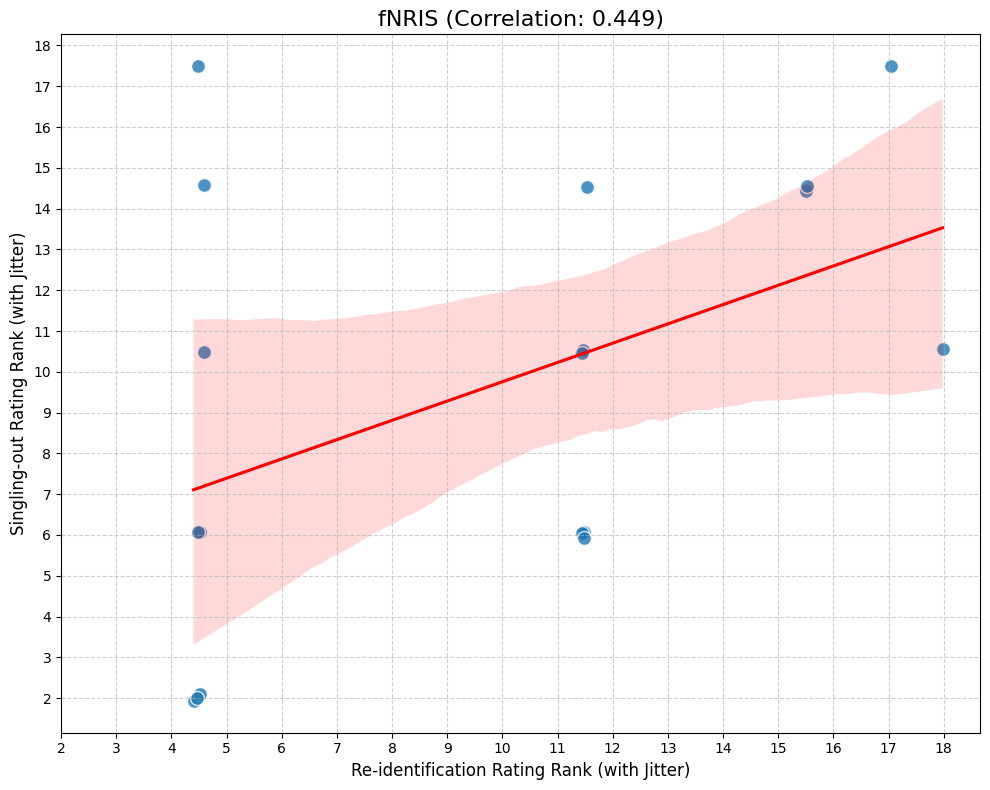

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if not all_ratings_df.empty:
    # Calculate ranks for Re-identification and Singling-out ratings
    all_ratings_df['Re-identification_rank'] = all_ratings_df.groupby('Data Type')['Re-identification'].rank(method='average')
    all_ratings_df['Singling-out_rank'] = all_ratings_df.groupby('Data Type')['Singling-out'].rank(method='average')

    # Add a small random jitter to x and y ranks to visualize overlapping points
    jitter_amount = 0.1 # Adjust this value as needed
    all_ratings_df['Re-identification_rank_jittered'] = all_ratings_df['Re-identification_rank'] + np.random.uniform(-jitter_amount, jitter_amount, len(all_ratings_df))
    all_ratings_df['Singling-out_rank_jittered'] = all_ratings_df['Singling-out_rank'] + np.random.uniform(-jitter_amount, jitter_amount, len(all_ratings_df))

    unique_categories = all_ratings_df['Superordinate Category'].unique()

    # Create a separate plot for each superordinate category
    for category in unique_categories:
        category_df = all_ratings_df[all_ratings_df['Superordinate Category'] == category]

        if not category_df.empty:
            plt.figure(figsize=(10, 8))
            sns.regplot(
                x='Re-identification_rank_jittered',
                y='Singling-out_rank_jittered',
                data=category_df,
                scatter_kws={'s': 100, 'alpha': 0.8, 'edgecolors': 'w'},
                line_kws={'color': 'red'},
                ci=95 # Show 95% confidence interval for the regression line
            )
            # Update the title to include only the superordinate name and correlation value
            if category in category_correlations:
                plt.title(f'{category} (Correlation: {category_correlations[category]:.3f})', fontsize=16)
            else:
                plt.title(f'{category}', fontsize=16)

            plt.xlabel('Re-identification Rating Rank (with Jitter)', fontsize=12)
            plt.ylabel('Singling-out Rating Rank (with Jitter)', fontsize=12)

            min_rank = min(category_df['Re-identification_rank'].min(), category_df['Singling-out_rank'].min())
            max_rank = max(category_df['Re-identification_rank'].max(), category_df['Singling-out_rank'].max())
            plt.xticks(np.arange(np.floor(min_rank), np.ceil(max_rank) + 1, 1))
            plt.yticks(np.arange(np.floor(min_rank), np.ceil(max_rank) + 1, 1))
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.tight_layout()
            plt.show()
        else:
            print(f"No data to plot for category: {category}")
else:
    print("Cannot create scatter plots: No data available after cleaning and categorization.")